In [3]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [4]:
print(tf.__version__)
print(keras.__version__)


2.19.0
3.10.0


In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()  # downloads if not cached


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
x_train = (x_train.astype("float32") / 255.0)[..., None]
x_test  = (x_test.astype("float32")  / 255.0)[..., None]


In [7]:
print("Train:", x_train.shape, "Test:", x_test.shape)


Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


In [8]:
USE_CONV_AE = True
LATENT_DIM  = 32           # bottleneck size for dense AE
EPOCHS_AE   = 11
BATCH_SIZE  = 256
AE_PATH     = "mnist_autoencoder.keras"
ENC_PATH    = "mnist_encoder.keras"

In [9]:
inputs = keras.Input(shape=(28, 28, 1), name="img")

In [10]:
if USE_CONV_AE:
    # ----- Convolutional AE -----
    # Encoder
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = layers.MaxPool2D()(x)                        # 14x14
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPool2D()(x)                        # 7x7
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)  # 7x7x128
    latent = layers.GlobalAveragePooling2D(name="latent")(x)         # (128,)
    # Keep a reshape for decoder
    # Decoder
    d = layers.Reshape((1, 1, 128))(latent)
    d = layers.Conv2DTranspose(128, 7, activation="relu")(d)         # 7x7
    d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)   # 14x14
    d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)   # 28x28
    outputs = layers.Conv2D(1, 3, padding="same", activation="sigmoid")(d)
else:
    # ----- Dense AE -----
    x = layers.Flatten()(inputs)                     # 784
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    latent = layers.Dense(LATENT_DIM, name="latent")(x)  # linear latent (you can add activation if desired)

    d = layers.Dense(128, activation="relu")(latent)
    d = layers.Dense(256, activation="relu")(d)
    d = layers.Dense(28 * 28, activation="sigmoid")(d)
    outputs = layers.Reshape((28, 28, 1))(d)


In [11]:
autoencoder = keras.Model(inputs, outputs, name="autoencoder")
encoder = keras.Model(inputs, latent, name="encoder")

In [12]:
autoencoder.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
autoencoder.summary()
encoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (GlobalAveragePooling2D) │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       802,944 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,161 (3.77 MB)

 Trainable params: 988,161 (3.77 MB)

 Non-trainable params: 0 (0.00 B)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (GlobalAveragePooling2D) │ (None, 128)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:

history_ae = autoencoder.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    epochs=EPOCHS_AE,
    batch_size=BATCH_SIZE,
    verbose=2
)

Epoch 1/11
235/235 - 16s - 69ms/step - loss: 0.0743 - val_loss: 0.0611
Epoch 2/11
235/235 - 4s - 18ms/step - loss: 0.0580 - val_loss: 0.0517
Epoch 3/11
235/235 - 4s - 18ms/step - loss: 0.0417 - val_loss: 0.0345
Epoch 4/11
235/235 - 4s - 19ms/step - loss: 0.0304 - val_loss: 0.0263
Epoch 5/11
235/235 - 4s - 18ms/step - loss: 0.0246 - val_loss: 0.0220
Epoch 6/11
235/235 - 4s - 19ms/step - loss: 0.0209 - val_loss: 0.0196
Epoch 7/11
235/235 - 4s - 19ms/step - loss: 0.0185 - val_loss: 0.0170
Epoch 8/11
235/235 - 4s - 19ms/step - loss: 0.0168 - val_loss: 0.0159
Epoch 9/11
235/235 - 5s - 19ms/step - loss: 0.0155 - val_loss: 0.0146
Epoch 10/11
235/235 - 4s - 19ms/step - loss: 0.0144 - val_loss: 0.0135
Epoch 11/11
235/235 - 4s - 19ms/step - loss: 0.0135 - val_loss: 0.0129


In [14]:
autoencoder.save(AE_PATH)
encoder.save(ENC_PATH)
print(f"Saved AE -> {AE_PATH}\nSaved encoder -> {ENC_PATH}")

Saved AE -> mnist_autoencoder.keras
Saved encoder -> mnist_encoder.keras


In [15]:
n = 10
idx = np.random.choice(len(x_test), n, replace=False)
x_batch = x_test[idx]
recons  = autoencoder.predict(x_batch, verbose=0)


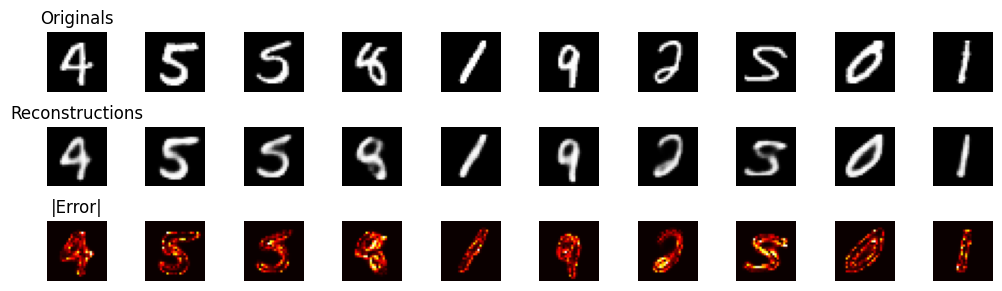

In [16]:
plt.figure(figsize=(n, 3))
for i in range(n):
    # originals
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_batch[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Originals")
    # reconstructions
    ax = plt.subplot(3, n, n + i + 1)
    plt.imshow(recons[i].squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0: ax.set_title("Reconstructions")
    # absolute error
    ax = plt.subplot(3, n, 2*n + i + 1)
    plt.imshow(np.abs(x_batch[i] - recons[i]).squeeze(), cmap="hot")
    plt.axis("off")
    if i == 0: ax.set_title("|Error|")
plt.tight_layout(); plt.show()


In [17]:
from skimage.metrics import structural_similarity as ssim
mse = np.mean((x_test - autoencoder.predict(x_test, verbose=0))**2)


In [18]:
ssim_vals = [ssim(x_test[i].squeeze(), autoencoder.predict(x_test[i:i+1]).squeeze(), data_range=1.0) for i in range(500)]
print(f"Test MSE (recon): {mse:.6f}")
print(f"Mean SSIM (500 samples): {np.mean(ssim_vals):.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

In [19]:
x_train_latent = encoder.predict(x_train, batch_size=512, verbose=0)
x_test_latent  = encoder.predict(x_test,  batch_size=512, verbose=0)
print("Latent shapes:", x_train_latent.shape, x_test_latent.shape)


Latent shapes: (60000, 128) (10000, 128)


In [20]:
clf_inputs = keras.Input(shape=x_train_latent.shape[1:], name="latent_in")
z = layers.Dense(64, activation="relu")(clf_inputs)
z = layers.Dropout(0.3)(z)
z = layers.Dense(64, activation="relu")(z)
clf_outputs = layers.Dense(10, activation="softmax")(z)


In [21]:
clf = keras.Model(clf_inputs, clf_outputs, name="latent_classifier")
clf.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
clf.summary()


Model: "latent_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent_in (InputLayer)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,066 (51.04 KB)

 Trainable params: 13,066 (51.04 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
EPOCHS_CLF = 10
history_clf = clf.fit(
    x_train_latent, y_train,
    validation_data=(x_test_latent, y_test),
    epochs=EPOCHS_CLF,
    batch_size=256,
    verbose=2
)

Epoch 1/10
235/235 - 5s - 20ms/step - accuracy: 0.6551 - loss: 1.0910 - val_accuracy: 0.9070 - val_loss: 0.3570
Epoch 2/10
235/235 - 1s - 3ms/step - accuracy: 0.8819 - loss: 0.3986 - val_accuracy: 0.9425 - val_loss: 0.2022
Epoch 3/10
235/235 - 1s - 3ms/step - accuracy: 0.9151 - loss: 0.2885 - val_accuracy: 0.9507 - val_loss: 0.1626
Epoch 4/10
235/235 - 1s - 4ms/step - accuracy: 0.9275 - loss: 0.2421 - val_accuracy: 0.9553 - val_loss: 0.1428
Epoch 5/10
235/235 - 1s - 4ms/step - accuracy: 0.9360 - loss: 0.2144 - val_accuracy: 0.9596 - val_loss: 0.1275
Epoch 6/10
235/235 - 1s - 4ms/step - accuracy: 0.9424 - loss: 0.1947 - val_accuracy: 0.9608 - val_loss: 0.1209
Epoch 7/10
235/235 - 1s - 3ms/step - accuracy: 0.9447 - loss: 0.1848 - val_accuracy: 0.9644 - val_loss: 0.1116
Epoch 8/10
235/235 - 1s - 3ms/step - accuracy: 0.9475 - loss: 0.1741 - val_accuracy: 0.9671 - val_loss: 0.1030
Epoch 9/10
235/235 - 1s - 3ms/step - accuracy: 0.9491 - loss: 0.1694 - val_accuracy: 0.9667 - val_loss: 0.1012


In [23]:
test_loss, test_acc = clf.evaluate(x_test_latent, y_test, verbose=0)
print(f"Latent-MLP Test accuracy: {test_acc:.4f}")

Latent-MLP Test accuracy: 0.9668
